In [8]:
import pandas as pd
from pathlib import Path

raw_data_dir = Path('../data/raw')

def load_csv_safe(file_path: Path) -> pd.DataFrame: # <-- Added explicit return type
    encodings_to_try = ['utf-8', 'latin1', 'cp1252']
    
    for enc in encodings_to_try:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f"✅ Loaded: {file_path.name:<25} (Encoding: {enc})")
            return df
        except UnicodeDecodeError:
            continue
        except FileNotFoundError:
            # Instead of returning None, raise the error to stop execution
            raise FileNotFoundError(f"❌ Error: {file_path.name} not found at {file_path}")
            
    # If all encodings fail, raise a ValueError
    raise ValueError(f"⚠️ Warning: Could not decode {file_path.name} with {encodings_to_try}")

# Load each dataset individually using the helper function
print("Attempting to load datasets...\n" + "-"*45)

df_test_soc      = load_csv_safe(raw_data_dir / 'esa_eo4_test_soc.csv')
df_train_soc     = load_csv_safe(raw_data_dir / 'esa_eo4_train_soc.csv')
df_rural_carbon  = load_csv_safe(raw_data_dir / 'rural_carbon_dataset1.csv')
df_srdb_data     = load_csv_safe(raw_data_dir / 'srdb-data-V5.csv')
df_srdb_eq       = load_csv_safe(raw_data_dir / 'srdb-equations-V5.csv')
df_srdb_studies  = load_csv_safe(raw_data_dir / 'srdb-studies-V5.csv')

print("-" * 45 + "\nAll files processed.")

Attempting to load datasets...
---------------------------------------------
✅ Loaded: esa_eo4_test_soc.csv      (Encoding: utf-8)
✅ Loaded: esa_eo4_train_soc.csv     (Encoding: utf-8)
✅ Loaded: rural_carbon_dataset1.csv (Encoding: utf-8)
✅ Loaded: srdb-data-V5.csv          (Encoding: utf-8)
✅ Loaded: srdb-equations-V5.csv     (Encoding: utf-8)


C:\Users\justi\AppData\Local\Temp\ipykernel_37124\2481900843.py:11: DtypeWarning: Columns (4,39,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding=enc)


✅ Loaded: srdb-studies-V5.csv       (Encoding: latin1)
---------------------------------------------
All files processed.


In [3]:
import pandas as pd

def analyze_dataset(df, dataset_name):
    """Runs standard exploratory data analysis checks on a given DataFrame."""
    
    print(f"\n{'-'*50}")
    print(f"DATASET: {dataset_name}")
    print(f"{'-'*50}")
    
    # 1. Show dimensions
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # 2. Show full column info (no truncation)
    print("\nColumn Info:")
    df.info(verbose=True, show_counts=True, max_cols=None)
    
    # 3. Show first 5 rows with all columns visible
    # Uncomment the two lines below if you are running this in a Jupyter Notebook
    # print("\nFirst 5 rows:")
    # display(df.head())
    
    # 4. Check for missing values
    null_count = df.isnull().sum().sum()
    if null_count > 0:
        print(f"\nTotal Missing Values: {null_count}")
    else:
        print("\nNo missing values detected.")

# Assuming your datasets are already loaded into memory from your loader script:
# rural_data, esa_data, srdb_data = load_all_data()

# Pass each dataset into the function one by one
analyze_dataset(df_rural_carbon, "Rural Carbon Dataset")
analyze_dataset(df_train_soc, "ESA Satellite Training Dataset")
analyze_dataset(df_test_soc, "ESA Satellite Test Dataset")
analyze_dataset(df_srdb_data, "SRDB Global Benchmark Dataset")

# If you also want to analyze the metadata reference files:
analyze_dataset(df_srdb_eq, "SRDB Equations")
analyze_dataset(df_srdb_studies, "SRDB Studies")


--------------------------------------------------
DATASET: Rural Carbon Dataset
--------------------------------------------------
Shape: 3000 rows, 13 columns

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Region                     3000 non-null   object 
 1   Month                      3000 non-null   int64  
 2   Fertilizer_Usage_kg        3000 non-null   float64
 3   Crop_Type                  3000 non-null   object 
 4   Crop_Area_ha               3000 non-null   float64
 5   Livestock_Cows             3000 non-null   int64  
 6   Livestock_Pigs             3000 non-null   int64  
 7   Household_Energy_kWh       3000 non-null   float64
 8   Renewable_Energy_Fraction  3000 non-null   float64
 9   Temperature_C              3000 non-null   float64
 10  Rainfall_mm                3000 non-null

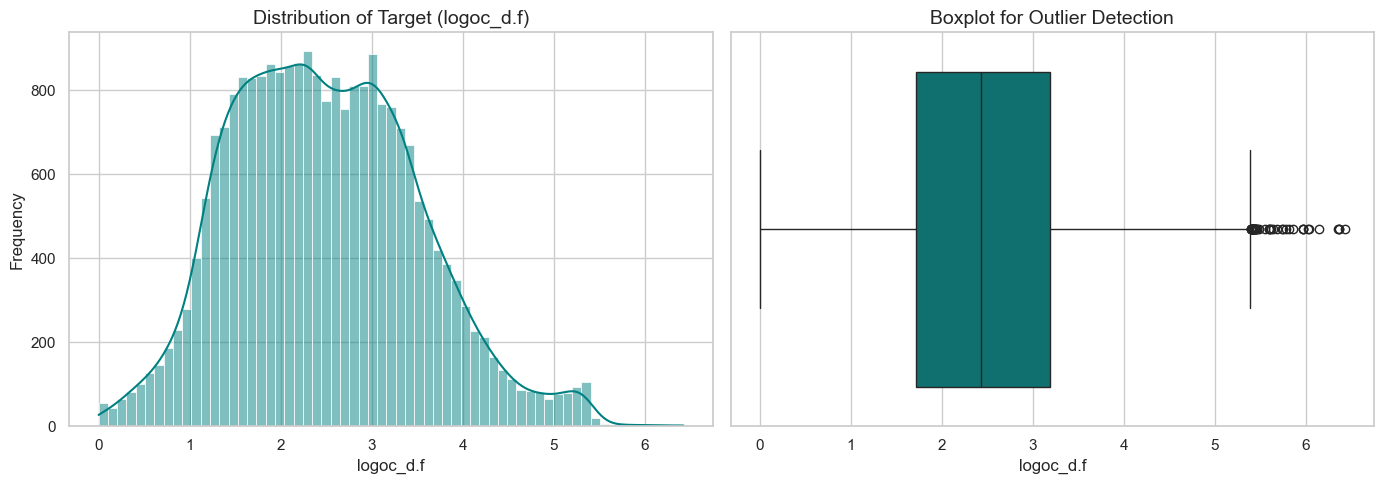

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------------------------------
# 1. Histogram with KDE (Kernel Density Estimate)
# --------------------------------------------------
# This helps check for skewness and overall distribution shape
sns.histplot(df_train_soc['logoc_d.f'], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribution of Target (logoc_d.f)', fontsize=14)
axes[0].set_xlabel('logoc_d.f')
axes[0].set_ylabel('Frequency')

# --------------------------------------------------
# 2. Boxplot
# --------------------------------------------------
# This is the standard method for identifying statistical outliers
sns.boxplot(x=df_train_soc['logoc_d.f'], color='teal', ax=axes[1])
axes[1].set_title('Boxplot for Outlier Detection', fontsize=14)
axes[1].set_xlabel('logoc_d.f')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

Calculated upper bound for outliers: 5.39
Total standard observations: 23849
Total high-carbon outliers detected: 49


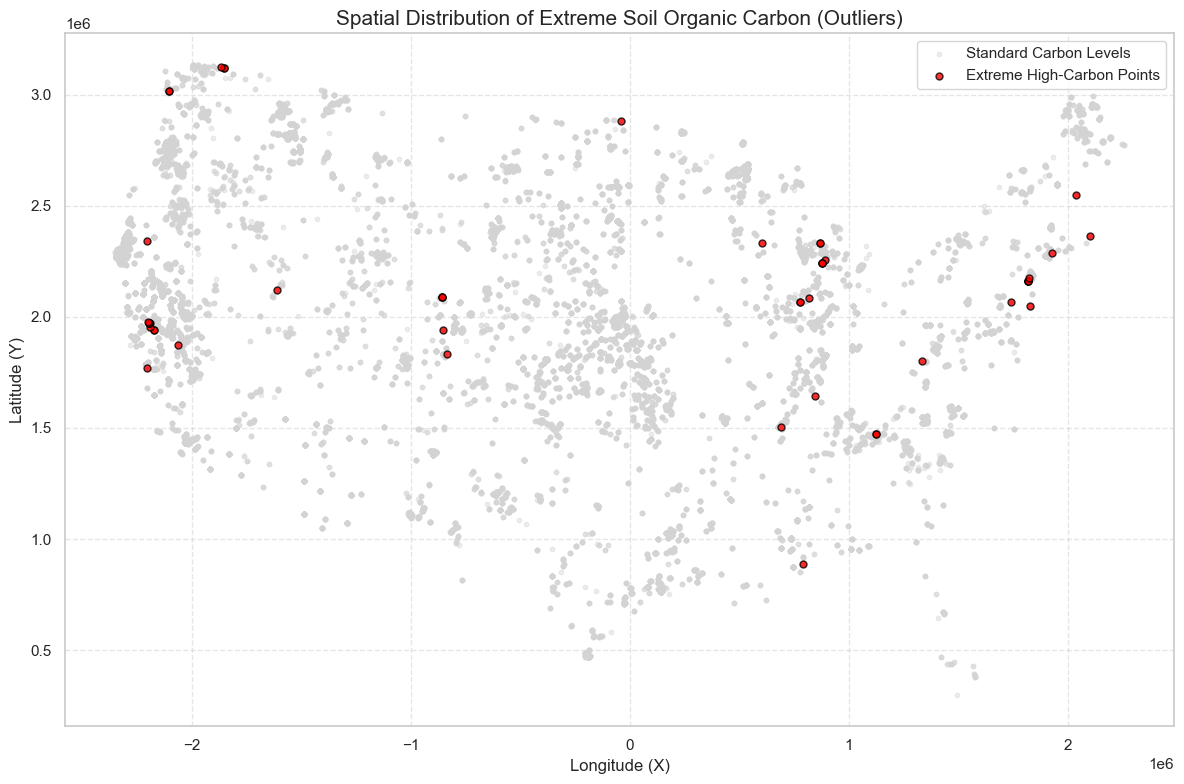

In [5]:
import matplotlib.pyplot as plt

# 1. Calculate the statistical Upper Bound using IQR
Q1 = df_train_soc['logoc_d.f'].quantile(0.25)
Q3 = df_train_soc['logoc_d.f'].quantile(0.75)
IQR = Q3 - Q1

# Any value above this upper bound is considered a statistical outlier
upper_bound = Q3 + 1.5 * IQR
print(f"Calculated upper bound for outliers: {upper_bound:.2f}")

# 2. Separate the data
df_normal = df_train_soc[df_train_soc['logoc_d.f'] <= upper_bound]
df_outliers = df_train_soc[df_train_soc['logoc_d.f'] > upper_bound]

print(f"Total standard observations: {len(df_normal)}")
print(f"Total high-carbon outliers detected: {len(df_outliers)}")

# 3. Plot the spatial distribution
plt.figure(figsize=(12, 8))

# Plot the standard data first (as a faint background map)
plt.scatter(df_normal['X'], df_normal['Y'], 
            c='lightgray', alpha=0.4, s=10, label='Standard Carbon Levels')

# Plot the outliers on top
plt.scatter(df_outliers['X'], df_outliers['Y'], 
            c='red', alpha=0.8, s=25, edgecolor='black', label='Extreme High-Carbon Points')

plt.title('Spatial Distribution of Extreme Soil Organic Carbon (Outliers)', fontsize=15)
plt.xlabel('Longitude (X)')
plt.ylabel('Latitude (Y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Calculating feature correlations... (This may take a moment)


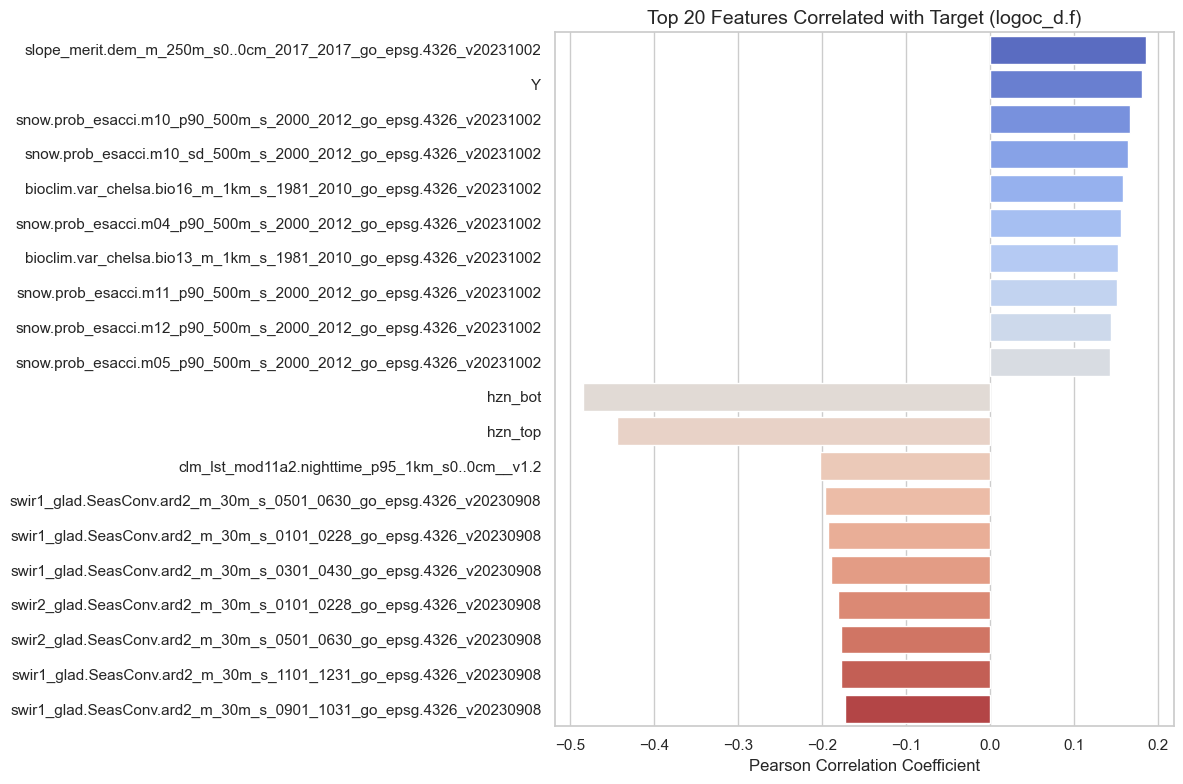

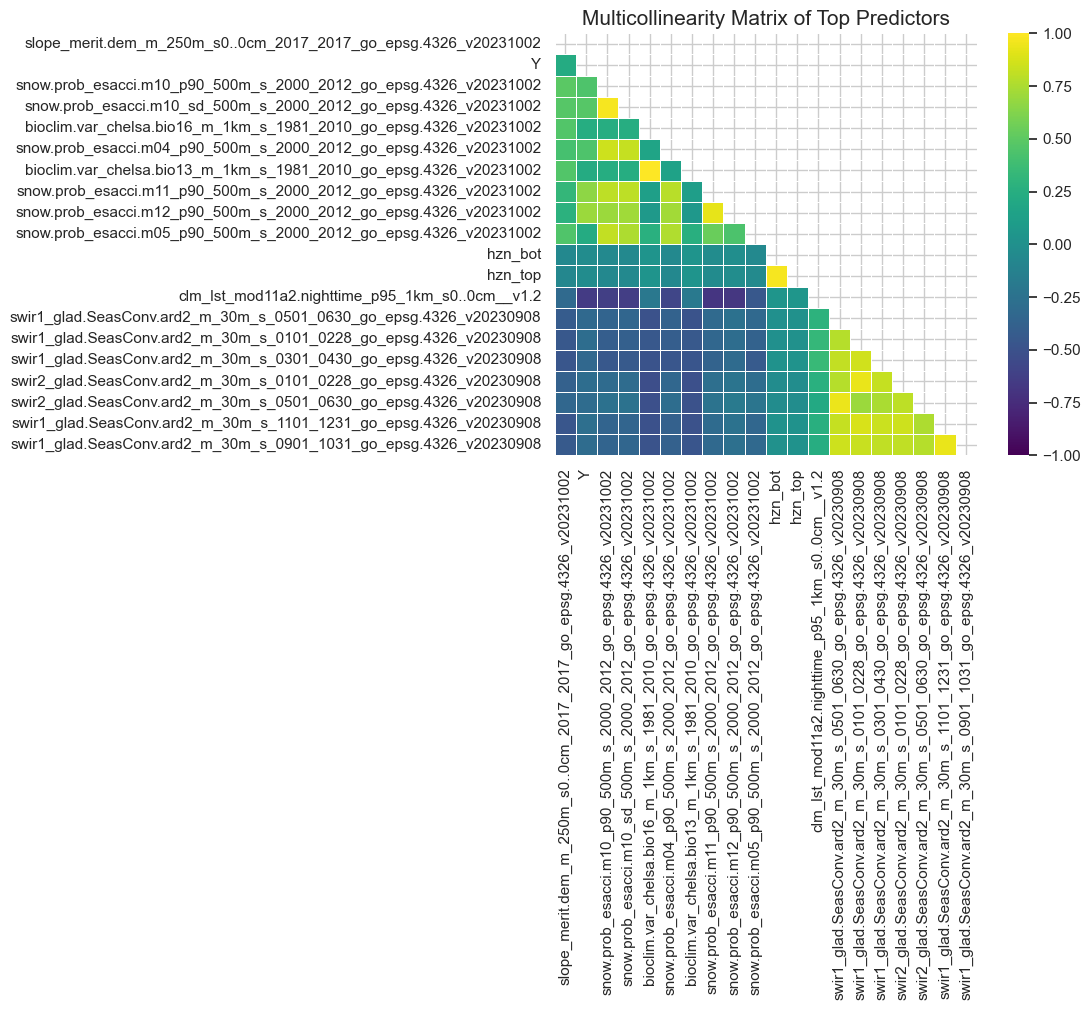

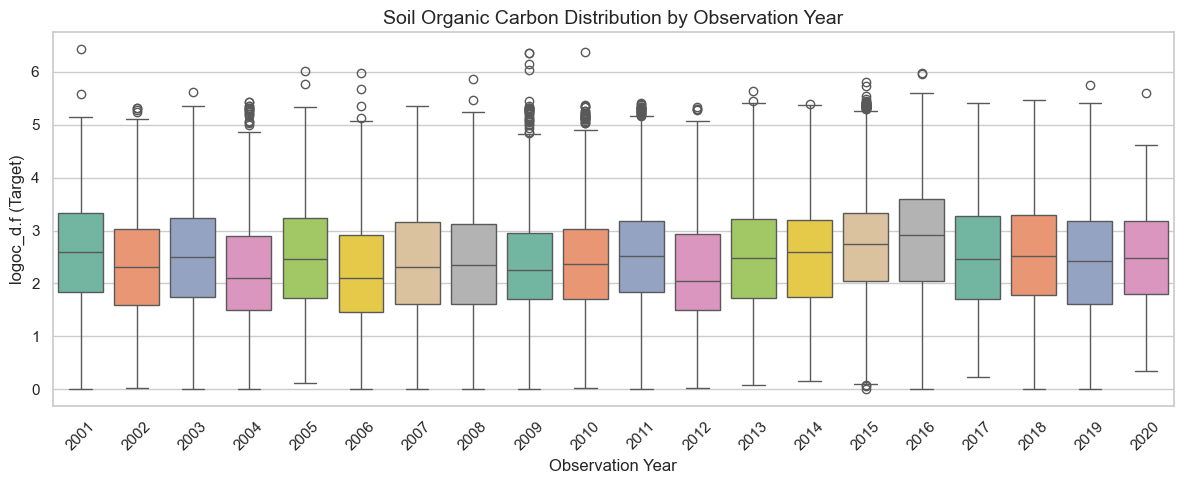

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set standard visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# EDA 1: Feature-Target Correlation
# ==========================================
print("Calculating feature correlations... (This may take a moment)")
# Calculate correlations with the target variable only
correlations = df_train_soc.corr(numeric_only=True)['logoc_d.f'].drop('logoc_d.f')

# Get the top 10 positive and top 10 negative correlated features
top_positive = correlations.nlargest(10)
top_negative = correlations.nsmallest(10)

# Combine into a single dataframe for Pylance-friendly plotting
top_features_df = pd.concat([top_positive, top_negative]).reset_index()
top_features_df.columns = ['Feature', 'Correlation']

plt.figure(figsize=(12, 8))
sns.barplot(data=top_features_df, x='Correlation', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Top 20 Features Correlated with Target (logoc_d.f)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# EDA 2: Multicollinearity Check
# ==========================================
# Get the names of those top features
top_feature_names = top_features_df['Feature'].tolist()

plt.figure(figsize=(12, 10))
# Calculate the correlation matrix for JUST these top features
corr_matrix = df_train_soc[top_feature_names].corr()

# Create a triangular mask to remove duplicate information (top right half)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='viridis', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)
plt.title('Multicollinearity Matrix of Top Predictors', fontsize=15)
plt.tight_layout()
plt.show()

# ==========================================
# EDA 3: Temporal Stability Analysis
# ==========================================
plt.figure(figsize=(12, 5))

# Boxplot to see how carbon levels vary by observation year
sns.boxplot(data=df_train_soc, x='observation_year', y='logoc_d.f', palette='Set2', hue='observation_year', legend=False)

plt.title('Soil Organic Carbon Distribution by Observation Year', fontsize=14)
plt.xlabel('Observation Year')
plt.ylabel('logoc_d.f (Target)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def apply_pca_to_group(df, column_substring, n_components=1, prefix='pca'):
    """
    Finds all columns containing a specific substring, scales them, 
    applies PCA, and replaces the originals with the new components.
    """
    # 1. Identify the columns belonging to this group
    target_cols = [col for col in df.columns if column_substring in col]
    
    if not target_cols:
        print(f"No columns found containing '{column_substring}'")
        return df
        
    print(f"Found {len(target_cols)} columns for '{column_substring}'. Compressing to {n_components} component(s)...")
    
    # 2. Extract and scale the data
    X = df[target_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. Apply PCA
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(X_scaled)
    
    # Print how much original information (variance) was kept
    explained_variance = sum(pca.explained_variance_ratio_) * 100
    print(f"✅ Retained {explained_variance:.2f}% of the original information.\n")
    
    # 4. Create new column names (e.g., pca_swir1_0)
    new_col_names = [f"{prefix}_{column_substring}_{i}" for i in range(n_components)]
    df_pca = pd.DataFrame(pca_features, columns=new_col_names, index=df.index)
    
    # 5. Drop original columns and join the new PCA columns
    df_reduced = df.drop(columns=target_cols)
    df_reduced = pd.concat([df_reduced, df_pca], axis=1)
    
    return df_reduced

# ==========================================
# Apply the function to our highly correlated groups
# ==========================================

# 1. Reset our engineered dataframe back to the original
df_train_engineered = df_train_soc.copy()

# 2. Re-apply the successful SWIR compressions
df_train_engineered = apply_pca_to_group(df_train_engineered, 'swir1', n_components=1)
df_train_engineered = apply_pca_to_group(df_train_engineered, 'swir2', n_components=1)

# 3. FIX: Increase snow components to capture seasonal variance
print("\n--- Fixing Snow Probability PCA ---")
df_train_engineered = apply_pca_to_group(df_train_engineered, 'snow.prob', n_components=4)

print(f"\nFinal optimized shape: {df_train_engineered.shape}")

Found 6 columns for 'swir1'. Compressing to 1 component(s)...
✅ Retained 86.33% of the original information.

Found 6 columns for 'swir2'. Compressing to 1 component(s)...
✅ Retained 87.24% of the original information.


--- Fixing Snow Probability PCA ---
Found 24 columns for 'snow.prob'. Compressing to 4 component(s)...
✅ Retained 81.21% of the original information.


Final optimized shape: (23898, 197)


In [13]:
df_train_engineered.info(verbose=True, show_counts=True, max_cols=None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23898 entries, 0 to 23897
Data columns (total 197 columns):
 #    Column                                                                                                                       Non-Null Count  Dtype  
---   ------                                                                                                                       --------------  -----  
 0    olc_id                                                                                                                       23898 non-null  object 
 1    UUID                                                                                                                         23898 non-null  object 
 2    X                                                                                                                            23898 non-null  float64
 3    Y                                                                                                            

Calculating feature correlations... (This may take a moment)


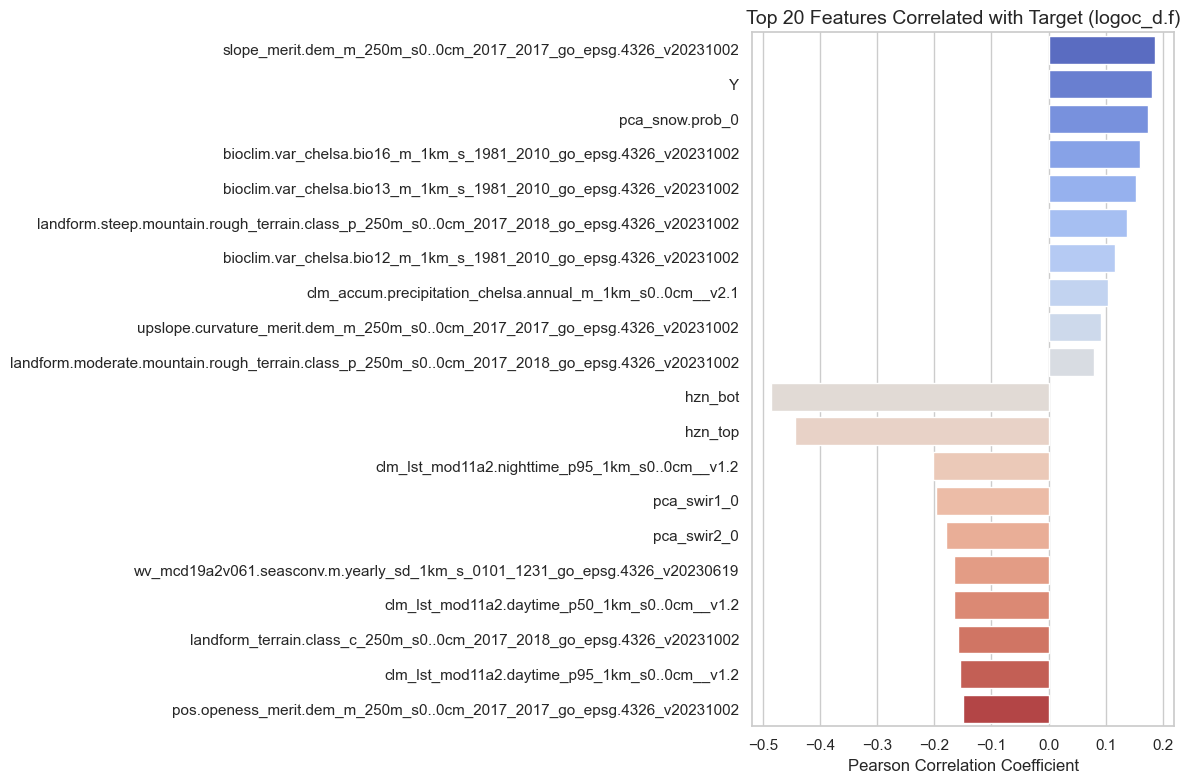

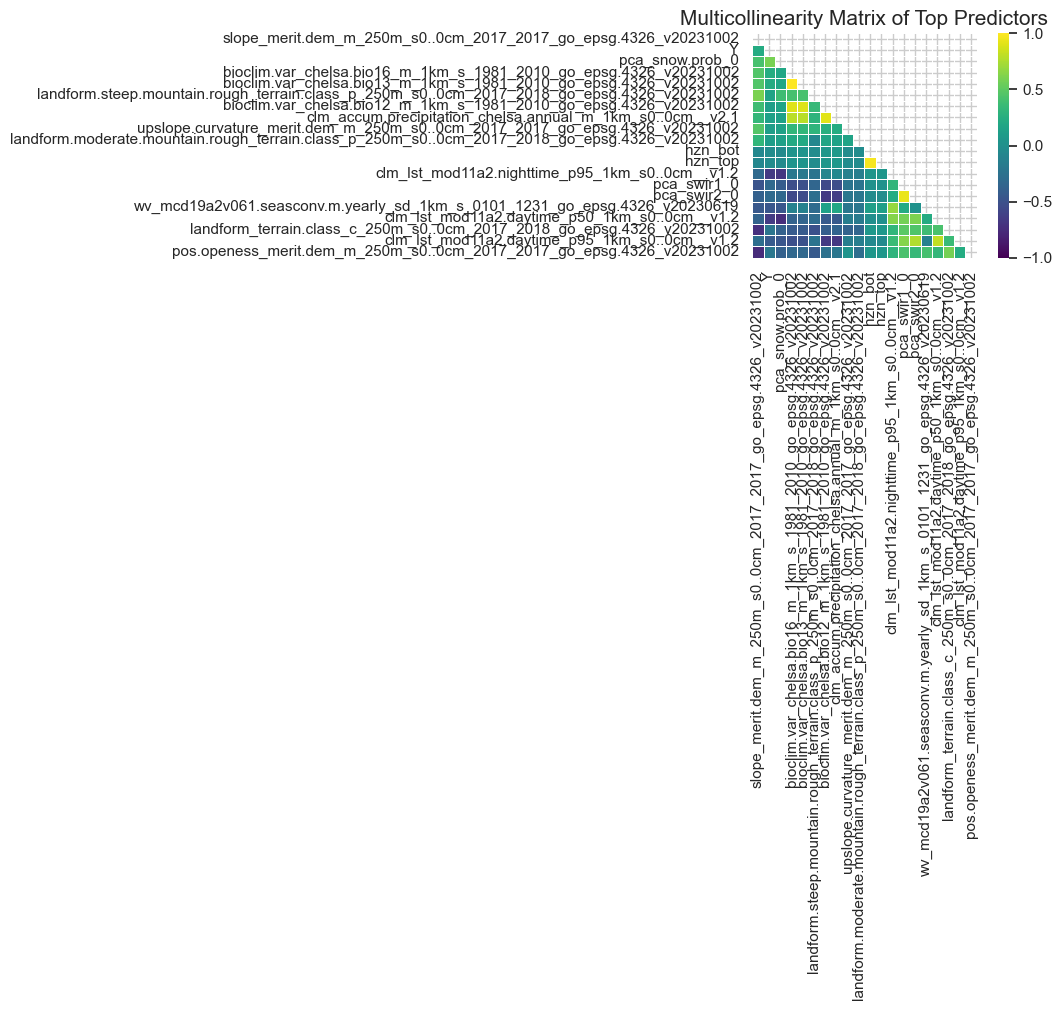

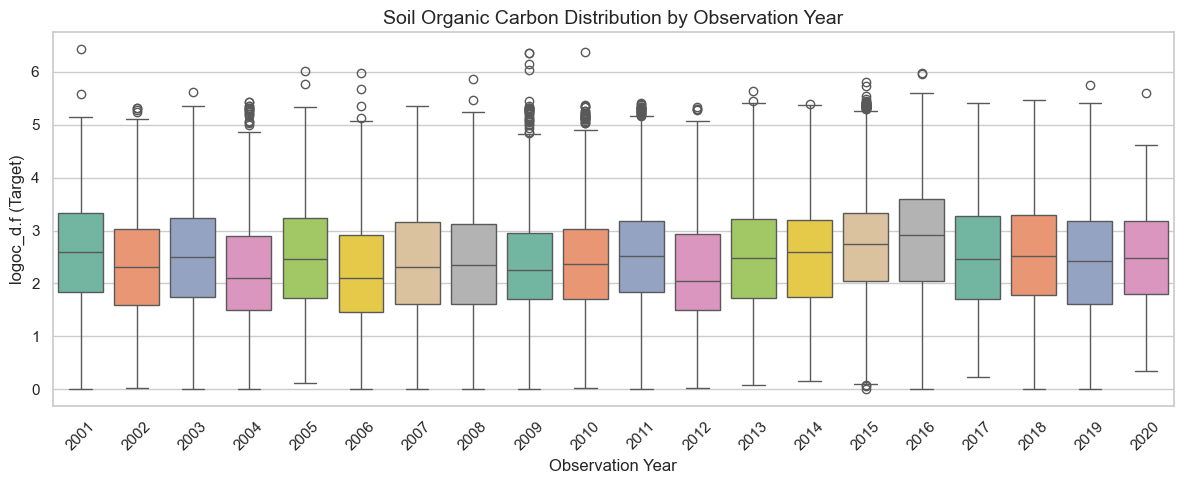

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set standard visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# EDA 1: Feature-Target Correlation
# ==========================================
print("Calculating feature correlations... (This may take a moment)")
# Calculate correlations with the target variable only
correlations = df_train_engineered.corr(numeric_only=True)['logoc_d.f'].drop('logoc_d.f')

# Get the top 10 positive and top 10 negative correlated features
top_positive = correlations.nlargest(10)
top_negative = correlations.nsmallest(10)

# Combine into a single dataframe for Pylance-friendly plotting
top_features_df = pd.concat([top_positive, top_negative]).reset_index()
top_features_df.columns = ['Feature', 'Correlation']

plt.figure(figsize=(12, 8))
sns.barplot(data=top_features_df, x='Correlation', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Top 20 Features Correlated with Target (logoc_d.f)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# EDA 2: Multicollinearity Check
# ==========================================
# Get the names of those top features
top_feature_names = top_features_df['Feature'].tolist()

plt.figure(figsize=(12, 10))
# Calculate the correlation matrix for JUST these top features
corr_matrix = df_train_engineered[top_feature_names].corr()

# Create a triangular mask to remove duplicate information (top right half)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='viridis', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)
plt.title('Multicollinearity Matrix of Top Predictors', fontsize=15)
plt.tight_layout()
plt.show()

# ==========================================
# EDA 3: Temporal Stability Analysis
# ==========================================
plt.figure(figsize=(12, 5))

# Boxplot to see how carbon levels vary by observation year
sns.boxplot(data=df_train_soc, x='observation_year', y='logoc_d.f', palette='Set2', hue='observation_year', legend=False)

plt.title('Soil Organic Carbon Distribution by Observation Year', fontsize=14)
plt.xlabel('Observation Year')
plt.ylabel('logoc_d.f (Target)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. Prepare Features (X) and Target (y)
# ==========================================
print("Preparing data for modeling...")

# Define the target
y = df_train_engineered['logoc_d.f']

# Define features: Drop the target and any non-predictive ID columns
# (Check your dataframe to make sure these ID column names are exactly correct)
cols_to_drop = ['logoc_d.f', 'olc_id', 'UUID', 'sample_id'] 

# Only drop columns that actually exist in the dataframe to avoid errors
existing_drops = [col for col in cols_to_drop if col in df_train_engineered.columns]
X = df_train_engineered.drop(columns=existing_drops)

# ==========================================
# 2. Train / Validation Split
# ==========================================
# We use 80% of data for training, 20% for testing the model's accuracy
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} rows, Validating on {X_val.shape[0]} rows.\n")

# ==========================================
# 3. Initialize and Train the Random Forest
# ==========================================
print("Training Random Forest... (This might take 1-2 minutes)")

# n_jobs=-1 tells your computer to use all available CPU cores to speed up training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ==========================================
# 4. Evaluate the Model
# ==========================================
# Make predictions on the validation set that the model has never seen
y_pred = rf_model.predict(X_val)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("✅ Training Complete!")
print("-" * 30)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score:         {r2:.4f}")
print("-" * 30)

Preparing data for modeling...
Training on 19118 rows, Validating on 4780 rows.

Training Random Forest... (This might take 1-2 minutes)
✅ Training Complete!
------------------------------
Root Mean Squared Error (RMSE): 0.5764
R-squared (R2) Score:         0.6859
------------------------------


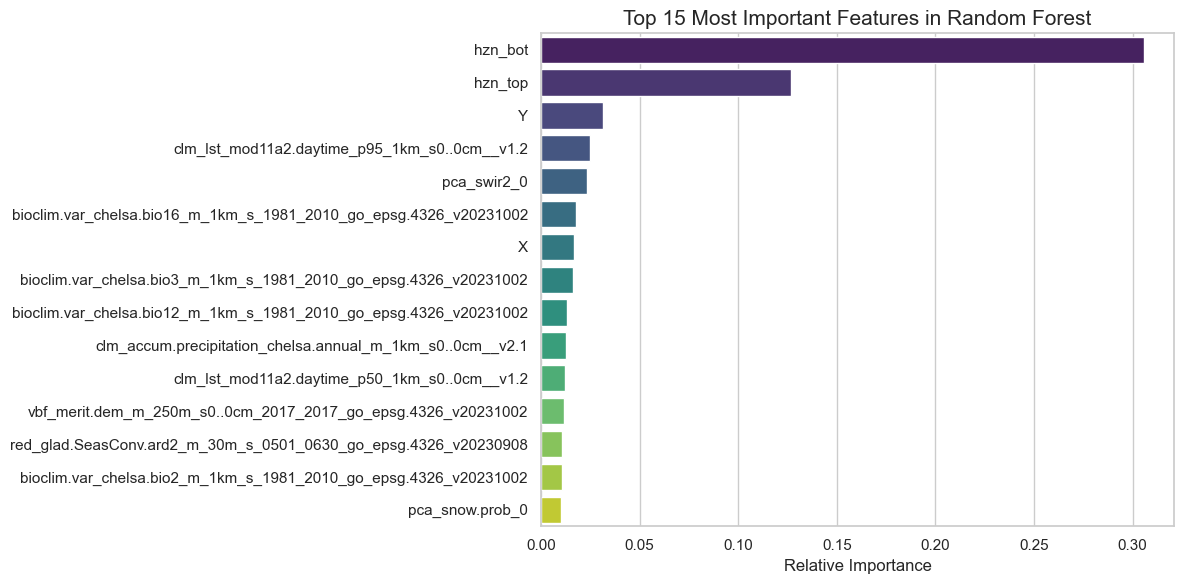

In [16]:
# ==========================================
# 5. Plot Feature Importances
# ==========================================
# Extract importances from the model
importances = rf_model.feature_importances_

# Create a dataframe for easy plotting
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance and get the top 15
top_15_rf = importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_15_rf, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features in Random Forest', fontsize=15)
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [17]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Training XGBoost Baseline...")

# Initialize XGBoost with standard baseline parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42, 
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_xgb)):.4f}")
print(f"XGBoost R2:   {r2_score(y_val, y_pred_xgb):.4f}")

Training XGBoost Baseline...
XGBoost RMSE: 0.5687
XGBoost R2:   0.6942


In [19]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import time

print("Starting XGBoost Hyperparameter Tuning...")
start_time = time.time()

# 1. Define the grid of parameters to test
param_distributions = {
    'n_estimators': [100, 300, 500],        # Number of trees
    'learning_rate': [0.01, 0.05, 0.1],     # How aggressively it learns
    'max_depth': [3, 5, 7, 9],              # How deep the trees can grow
    'subsample': [0.7, 0.8, 1.0],           # Percentage of data used per tree (prevents overfitting)
    'colsample_bytree': [0.7, 0.8, 1.0]     # Percentage of features used per tree
}

# 2. Set up the Random Search
xgb_random = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=20,                              # Try 20 random combinations
    cv=3,                                   # 3-fold cross validation
    scoring='r2',
    random_state=42,
    verbose=1,                              # Prints progress
    n_jobs=-1
)

# 3. Fit the models
xgb_random.fit(X_train, y_train)

# 4. Extract the best model and evaluate
# FIX: Use a single underscore at the end
best_xgb = xgb_random.best_estimator_
y_pred_tuned = best_xgb.predict(X_val)

end_time = time.time()

print("\n✅ Tuning Complete!")
print(f"Time taken: {(end_time - start_time) / 60:.1f} minutes")
print("-" * 40)
print(f"Best Parameters: {xgb_random.best_params_}")
print("-" * 40)
print(f"Tuned XGBoost RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_tuned)):.4f}")
print(f"Tuned XGBoost R2:   {r2_score(y_val, y_pred_tuned):.4f}")

Starting XGBoost Hyperparameter Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Tuning Complete!
Time taken: 5.9 minutes
----------------------------------------
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
----------------------------------------
Tuned XGBoost RMSE: 0.4997
Tuned XGBoost R2:   0.7639


In [20]:
%pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 1.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 1.2 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 1.1 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 1.1 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 1.0 MB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.7 MB 945.5 kB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.7 MB 945.5 kB/s eta 0:00:02
   ---------------------- ----------------- 1.6/2.7 MB 932.2 kB/s eta 0:00:02
   -------------------------- ------------- 1.8/2.7 MB 958.5 kB/s eta 0:00:01
   ----------------------

c:\Users\justi\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP values... (This takes a moment for 500 trees)


C:\Users\justi\AppData\Local\Temp\ipykernel_37124\1853098406.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


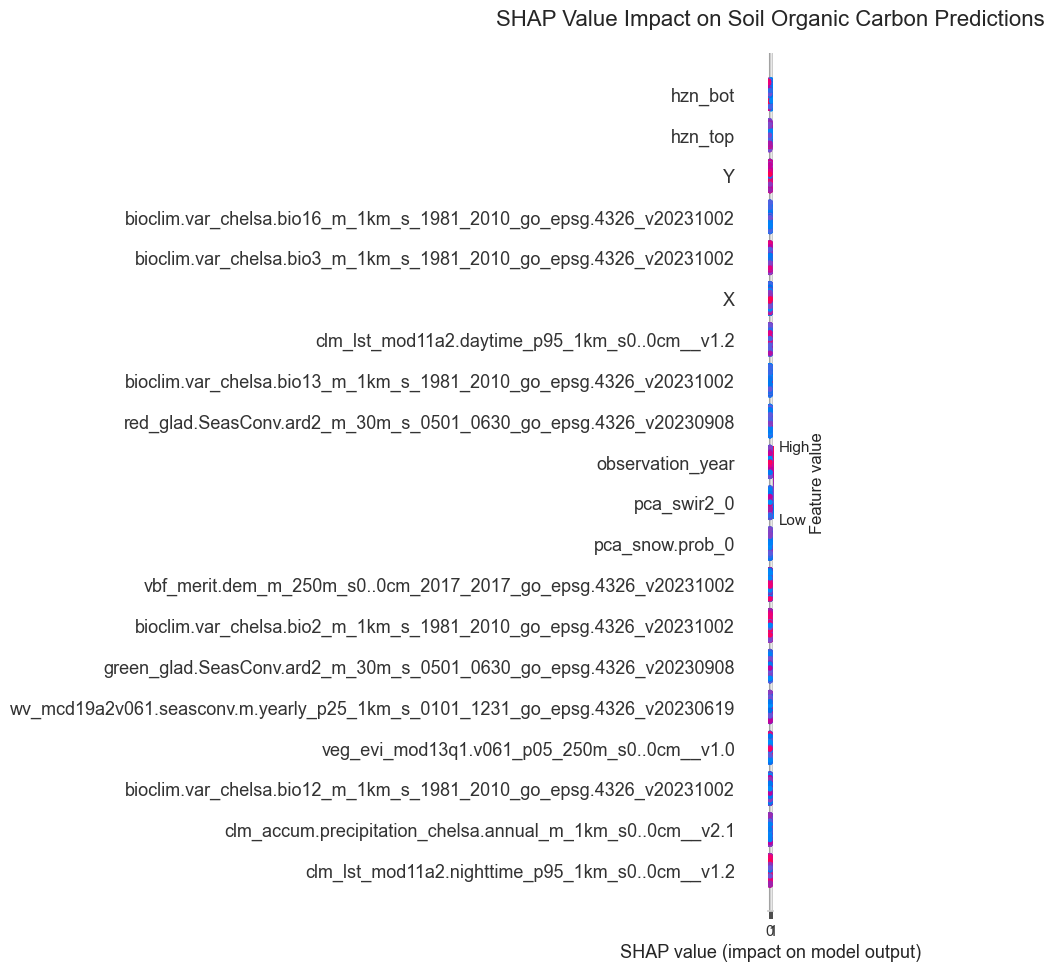

In [21]:
import shap
import matplotlib.pyplot as plt

print("Calculating SHAP values... (This takes a moment for 500 trees)")

# 1. Create the explainer using your tuned XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# 2. Calculate SHAP values for your validation set
# We use X_val so we are interpreting how it predicts on unseen data
shap_values = explainer.shap_values(X_val)

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, plot_type="dot", show=False)

# Formatting the plot for a clean presentation slide
plt.title('SHAP Value Impact on Soil Organic Carbon Predictions', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Calculating SHAP values with modern API...


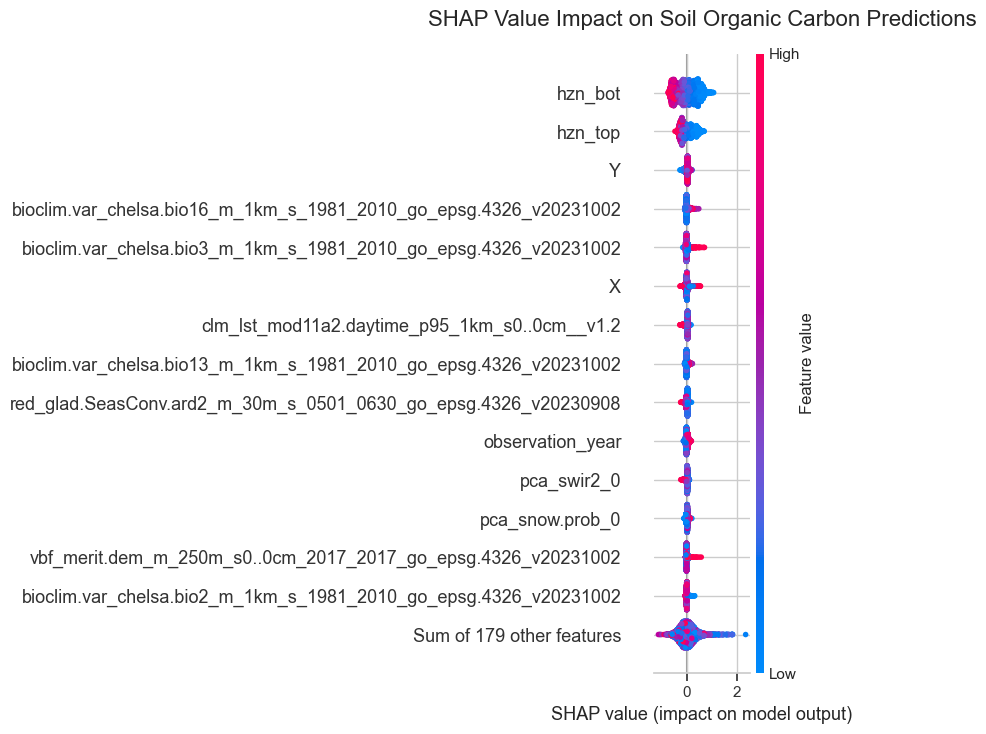

In [22]:
import shap
import matplotlib.pyplot as plt

print("Calculating SHAP values with modern API...")

# 1. Use the modern generic Explainer (it will auto-detect XGBoost)
explainer = shap.Explainer(best_xgb)

# 2. Calculate SHAP values (Notice we don't use .shap_values() anymore)
# This returns a rich SHAP object rather than just a raw numpy array
shap_values = explainer(X_val)

# 3. Generate the modern Beeswarm plot
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)

# Formatting
plt.title('SHAP Value Impact on Soil Organic Carbon Predictions', fontsize=16, pad=20)
plt.tight_layout()
plt.show()